<a href="https://colab.research.google.com/github/yana-g/graph-analysis/blob/main/05_Link_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stage 5: Link Prediction

This notebook builds and evaluates machine-learning models for predicting future collaborations between Israeli actors.

Temporal design:

- **Internal history:** 1990–2017
- **Internal validation:** new links formed in 2018–2020
- **Final history:** 1990–2020
- **Future evaluation:** new links formed in 2021–2025

The notebook includes graph features, centrality features, spectral embeddings, matrix factorization, several classifiers, future evaluation, realized and unrealized predictions, false-negative analysis, and cold-start analysis.


### 1. Imports


In [15]:
from pathlib import Path
from itertools import combinations
import math
import pickle
import random
import time

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy import sparse

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import SpectralEmbedding
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)


### 2. Load and Validate the Dataset

The notebook uses `movies_with_actors.csv` because the temporal split requires both actor names and movie years.


In [2]:
DATA_FILE = Path("movies_with_actors.csv")

if not DATA_FILE.exists():
    raise FileNotFoundError(
        "movies_with_actors.csv was not found. "
        "Run Stage 1 first and place the file next to this notebook."
    )

movies_df = pd.read_csv(
    DATA_FILE,
    encoding="utf-8-sig"
)

required_columns = {
    "page_id",
    "movie_title",
    "year"
}

missing_columns = required_columns.difference(
    movies_df.columns
)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

actor_columns = sorted(
    [
        column
        for column in movies_df.columns
        if column.startswith("actor_")
        and column != "actor_count"
    ],
    key=lambda column: int(column.split("_")[1])
)

if not actor_columns:
    raise ValueError("No actor columns were found.")

movies_df["year"] = pd.to_numeric(
    movies_df["year"],
    errors="coerce"
)

movies_df = (
    movies_df
    .dropna(subset=["page_id", "movie_title", "year"])
    .copy()
)

movies_df["year"] = movies_df["year"].astype(int)

print("Movies:", len(movies_df))
print("Actor columns:", actor_columns)
print(
    "Year range:",
    movies_df["year"].min(),
    "-",
    movies_df["year"].max()
)

display(movies_df.head())


Movies: 1155
Actor columns: ['actor_1', 'actor_2', 'actor_3', 'actor_4', 'actor_5', 'actor_6', 'actor_7', 'actor_8', 'actor_9', 'actor_10']
Year range: 1960 - 2026


,page_id,movie_title,year,genre,director,actor_count,extraction_source,error,actor_1,actor_2,actor_3,actor_4,actor_5,actor_6,actor_7,actor_8,actor_9,actor_10
0,1706365,איי לייק מייק (סרט),1960,קומדיה רומנטית,פיטר פריי,9,infobox+section,NaN,בתיה לנצט,חיים טופול,אילנה רובינא,גדעון זינגר,זאב ברלינסקי,אבנר חזקיהו,גאולה נוני,סיי גיטין,מאירה שור,NaN
1,631050,הם היו עשרה,1960,NaN,ברוך דינר,9,infobox,NaN,עודד תאומי,בומבה צור,ליאו פילר,גבריאל דגן,יהודה גבאי,ניסים עזיקרי,איתן פריבר,ישראל רובינצ'יק,נינט דינר,NaN
2,1486999,חולות לוהטים,1960,פעולה | דרמה,רפאל נוסבאום,9,infobox,NaN,דליה לביא,אורי זוהר,עודד תאומי,עודד קוטלר,גרט הופמן,אנ',נתן כוגן,גילה אלמגור,אסתר עופרים,NaN
3,2518194,רחל (סרט),1960,דרמה | פשע,נורי חביב,5,infobox,NaN,רחל טטרקו (חביב),דוד רם,יצחק בנש,מרגלית שמיט,ששון סער,NaN,NaN,NaN,NaN,NaN
4,2504743,תיקון קטן,1960,דרמה,חיים חפר | דן בן אמוץ,5,section,NaN,אורי זוהר,יהורם גאון,מישא אשרוב,גברי בנאי,"להקת הנח""ל",NaN,NaN,NaN,NaN,NaN


### 3. Prepare Movie and Edge Records


In [3]:
def clean_actor(value):
    """Return a clean actor name or an empty string."""
    if pd.isna(value):
        return ""

    actor = str(value).strip()

    if not actor or actor.casefold() == "nan":
        return ""

    return actor


def get_movie_actors(row):
    """Return unique cleaned actors for one movie."""
    actors = []
    seen = set()

    for column in actor_columns:
        actor = clean_actor(row[column])

        if not actor:
            continue

        key = actor.casefold()

        if key not in seen:
            seen.add(key)
            actors.append(actor)

    return actors


def build_movie_edge_records(dataframe):
    """Create one record per actor pair and movie."""
    records = []

    for _, row in dataframe.iterrows():
        actors = get_movie_actors(row)

        for actor_1, actor_2 in combinations(actors, 2):
            actor_a, actor_b = sorted(
                [actor_1, actor_2]
            )

            records.append({
                "actor_1": actor_a,
                "actor_2": actor_b,
                "movie_title": row["movie_title"],
                "year": int(row["year"]),
                "page_id": row["page_id"]
            })

    return pd.DataFrame(records)


edge_records_df = build_movie_edge_records(
    movies_df
)

print("Actor-pair movie records:", len(edge_records_df))
print(
    "Unique actor pairs:",
    edge_records_df[
        ["actor_1", "actor_2"]
    ].drop_duplicates().shape[0]
)

display(edge_records_df.head())


Actor-pair movie records: 29557
Unique actor pairs: 27896


,actor_1,actor_2,movie_title,year,page_id
0,בתיה לנצט,חיים טופול,איי לייק מייק (סרט),1960,1706365
1,אילנה רובינא,בתיה לנצט,איי לייק מייק (סרט),1960,1706365
2,בתיה לנצט,גדעון זינגר,איי לייק מייק (סרט),1960,1706365
3,בתיה לנצט,זאב ברלינסקי,איי לייק מייק (סרט),1960,1706365
4,אבנר חזקיהו,בתיה לנצט,איי לייק מייק (סרט),1960,1706365


### 4. Define the Temporal Windows


In [4]:
INTERNAL_HISTORY_START = 1990
INTERNAL_HISTORY_END = 2017
INTERNAL_FUTURE_START = 2018
INTERNAL_FUTURE_END = 2020

FINAL_HISTORY_START = 1990
FINAL_HISTORY_END = 2020
FINAL_FUTURE_START = 2021
FINAL_FUTURE_END = 2025


In [5]:
def canonical_edge(actor_1, actor_2):
    """Return a stable undirected edge tuple."""
    return tuple(sorted((actor_1, actor_2)))


def build_graph_for_years(
    dataframe,
    start_year,
    end_year
):
    """Build a weighted collaboration graph for a year range."""
    graph = nx.Graph()

    period_df = dataframe[
        dataframe["year"].between(
            start_year,
            end_year
        )
    ].copy()

    for _, row in period_df.iterrows():
        actors = get_movie_actors(row)

        graph.add_nodes_from(actors)

        for actor_1, actor_2 in combinations(actors, 2):
            if graph.has_edge(actor_1, actor_2):
                graph[actor_1][actor_2]["weight"] += 1
            else:
                graph.add_edge(
                    actor_1,
                    actor_2,
                    weight=1
                )

    return graph


def edge_set_for_years(
    edge_dataframe,
    start_year,
    end_year
):
    """Return unique collaboration edges formed in a year range."""
    period_edges = edge_dataframe[
        edge_dataframe["year"].between(
            start_year,
            end_year
        )
    ]

    return {
        canonical_edge(
            row.actor_1,
            row.actor_2
        )
        for row in period_edges.itertuples(index=False)
    }


def new_future_edges(
    history_graph,
    edge_dataframe,
    future_start,
    future_end
):
    """Return future edges that did not exist in the historical graph."""
    future_edges = edge_set_for_years(
        edge_dataframe,
        future_start,
        future_end
    )

    history_edges = {
        canonical_edge(u, v)
        for u, v in history_graph.edges()
    }

    return future_edges.difference(
        history_edges
    )


In [6]:
G_internal = build_graph_for_years(
    movies_df,
    INTERNAL_HISTORY_START,
    INTERNAL_HISTORY_END
)

internal_future_edges = new_future_edges(
    G_internal,
    edge_records_df,
    INTERNAL_FUTURE_START,
    INTERNAL_FUTURE_END
)

G_final = build_graph_for_years(
    movies_df,
    FINAL_HISTORY_START,
    FINAL_HISTORY_END
)

final_future_edges = new_future_edges(
    G_final,
    edge_records_df,
    FINAL_FUTURE_START,
    FINAL_FUTURE_END
)

print("Internal history graph")
print("Nodes:", G_internal.number_of_nodes())
print("Edges:", G_internal.number_of_edges())
print("New links in 2018–2020:", len(internal_future_edges))

print("\nFinal history graph")
print("Nodes:", G_final.number_of_nodes())
print("Edges:", G_final.number_of_edges())
print("New links in 2021–2025:", len(final_future_edges))


Internal history graph
Nodes: 2050
Edges: 15330
New links in 2018–2020: 1201

Final history graph
Nodes: 2198
Edges: 16531
New links in 2021–2025: 2736


### 5. Separate Evaluable and Cold-Start Future Links


In [7]:
def split_evaluable_and_cold_start(
    history_graph,
    future_edges
):
    """Split future positives into evaluable and cold-start edges."""
    historical_nodes = set(
        history_graph.nodes()
    )

    evaluable = set()
    cold_start = set()

    for edge in future_edges:
        if set(edge).issubset(historical_nodes):
            evaluable.add(edge)
        else:
            cold_start.add(edge)

    return evaluable, cold_start


internal_positive_edges, internal_cold_start_edges = (
    split_evaluable_and_cold_start(
        G_internal,
        internal_future_edges
    )
)

final_positive_edges, final_cold_start_edges = (
    split_evaluable_and_cold_start(
        G_final,
        final_future_edges
    )
)

print("Internal evaluable positives:", len(internal_positive_edges))
print("Internal cold-start positives:", len(internal_cold_start_edges))

print("\nFinal evaluable positives:", len(final_positive_edges))
print("Final cold-start positives:", len(final_cold_start_edges))


Internal evaluable positives: 454
Internal cold-start positives: 747

Final evaluable positives: 735
Final cold-start positives: 2001


### 6. Sample Negative Links


In [8]:
def sample_negative_edges(
    history_graph,
    positive_edges,
    excluded_future_edges,
    sample_size,
    seed=RANDOM_STATE
):
    """Sample valid negative actor pairs."""
    local_rng = np.random.default_rng(seed)
    nodes = np.array(list(history_graph.nodes()))

    history_edges = {
        canonical_edge(u, v)
        for u, v in history_graph.edges()
    }

    forbidden = (
        history_edges
        | set(positive_edges)
        | set(excluded_future_edges)
    )

    negatives = set()
    maximum_attempts = sample_size * 100
    attempts = 0

    while (
        len(negatives) < sample_size
        and attempts < maximum_attempts
    ):
        actor_1, actor_2 = local_rng.choice(
            nodes,
            size=2,
            replace=False
        )

        edge = canonical_edge(
            str(actor_1),
            str(actor_2)
        )

        if edge not in forbidden:
            negatives.add(edge)

        attempts += 1

    if len(negatives) < sample_size:
        raise RuntimeError(
            f"Could only sample {len(negatives)} "
            f"negative edges out of {sample_size} requested."
        )

    return negatives


internal_negative_edges = sample_negative_edges(
    G_internal,
    internal_positive_edges,
    internal_future_edges,
    sample_size=len(internal_positive_edges),
    seed=RANDOM_STATE
)

final_negative_edges = sample_negative_edges(
    G_final,
    final_positive_edges,
    final_future_edges,
    sample_size=len(final_positive_edges),
    seed=RANDOM_STATE + 1
)

print("Internal negatives:", len(internal_negative_edges))
print("Final negatives:", len(final_negative_edges))


Internal negatives: 454
Final negatives: 735


### 7. Compute Graph Context


In [9]:
def compute_graph_context(
    graph,
    seed=RANDOM_STATE
):
    """Compute node-level values used by pair features."""
    context = {}

    context["degree"] = dict(
        graph.degree()
    )

    context["weighted_degree"] = dict(
        graph.degree(weight="weight")
    )

    context["degree_centrality"] = (
        nx.degree_centrality(graph)
    )

    context["clustering"] = (
        nx.clustering(
            graph,
            weight="weight"
        )
    )

    context["pagerank"] = nx.pagerank(
        graph,
        weight="weight"
    )

    sample_k = min(
        250,
        graph.number_of_nodes()
    )

    context["betweenness"] = (
        nx.betweenness_centrality(
            graph,
            k=sample_k,
            normalized=True,
            weight=None,
            seed=seed
        )
    )

    communities = list(
        nx.community.louvain_communities(
            graph,
            weight="weight",
            seed=seed
        )
    )

    node_to_community = {}

    for community_id, community in enumerate(
        communities
    ):
        for node in community:
            node_to_community[node] = community_id

    context["community"] = node_to_community

    return context


### 8. Build Embedding and Matrix-Factorization Representations


In [16]:
def build_adjacency_matrix(graph):
    """
    Build a weighted sparse adjacency matrix with
    32-bit indices for scikit-learn compatibility.
    """
    nodes = list(graph.nodes())

    node_to_index = {
        node: index
        for index, node in enumerate(nodes)
    }

    adjacency = nx.to_scipy_sparse_array(
        graph,
        nodelist=nodes,
        weight="weight",
        dtype=np.float64,
        format="csr"
    )

    # Convert scipy sparse array to csr_matrix
    adjacency = sparse.csr_matrix(adjacency)

    # SpectralEmbedding requires 32-bit sparse indices
    adjacency.indices = adjacency.indices.astype(
        np.int32
    )

    adjacency.indptr = adjacency.indptr.astype(
        np.int32
    )

    return nodes, node_to_index, adjacency

### 9. Create Pair Features


In [11]:
GRAPH_FEATURE_COLUMNS = [
    "common_neighbors",
    "jaccard",
    "adamic_adar",
    "preferential_attachment",
    "resource_allocation",
    "shortest_path",
    "same_community",
    "degree_min",
    "degree_max",
    "degree_sum",
    "degree_difference",
    "weighted_degree_sum",
    "degree_centrality_sum",
    "betweenness_sum",
    "pagerank_sum",
    "clustering_mean"
]

SPECTRAL_FEATURE_COLUMNS = [
    "spectral_dot",
    "spectral_cosine",
    "spectral_l1",
    "spectral_l2"
]

SVD_FEATURE_COLUMNS = [
    "svd_dot",
    "svd_cosine",
    "svd_l1",
    "svd_l2"
]

ALL_FEATURE_COLUMNS = (
    GRAPH_FEATURE_COLUMNS
    + SPECTRAL_FEATURE_COLUMNS
    + SVD_FEATURE_COLUMNS
)


In [12]:
def safe_cosine(vector_1, vector_2):
    """Return cosine similarity with zero-vector protection."""
    denominator = (
        np.linalg.norm(vector_1)
        * np.linalg.norm(vector_2)
    )

    if denominator == 0:
        return 0.0

    return float(
        np.dot(vector_1, vector_2)
        / denominator
    )


def pair_vector_features(
    vector_1,
    vector_2,
    prefix
):
    """Create pair-level features from two vectors."""
    difference = vector_1 - vector_2

    return {
        f"{prefix}_dot": float(
            np.dot(vector_1, vector_2)
        ),
        f"{prefix}_cosine": safe_cosine(
            vector_1,
            vector_2
        ),
        f"{prefix}_l1": float(
            np.abs(difference).sum()
        ),
        f"{prefix}_l2": float(
            np.linalg.norm(difference)
        )
    }


def build_path_cache(
    graph,
    pairs,
    cutoff=7
):
    """Cache shortest paths for sample sources."""
    sources = {
        actor_1
        for actor_1, _ in pairs
    }

    cache = {}

    for source in sources:
        cache[source] = (
            nx.single_source_shortest_path_length(
                graph,
                source,
                cutoff=cutoff
            )
        )

    return cache


In [13]:
def create_feature_dataframe(
    graph,
    edges,
    labels,
    context,
    latent,
    path_cutoff=7
):
    """Create a complete feature DataFrame for actor pairs."""
    edges = list(edges)
    labels = list(labels)

    if len(edges) != len(labels):
        raise ValueError(
            "Edges and labels must have the same length."
        )

    path_cache = build_path_cache(
        graph,
        edges,
        cutoff=path_cutoff
    )

    rows = []

    for (
        actor_1,
        actor_2
    ), label in zip(edges, labels):
        common_neighbors = list(
            nx.common_neighbors(
                graph,
                actor_1,
                actor_2
            )
        )

        common_neighbor_count = len(
            common_neighbors
        )

        union_size = (
            context["degree"][actor_1]
            + context["degree"][actor_2]
            - common_neighbor_count
        )

        jaccard = (
            common_neighbor_count / union_size
            if union_size > 0
            else 0.0
        )

        adamic_adar = sum(
            1.0 / math.log(
                context["degree"][neighbor]
            )
            for neighbor in common_neighbors
            if context["degree"][neighbor] > 1
        )

        resource_allocation = sum(
            1.0 / context["degree"][neighbor]
            for neighbor in common_neighbors
            if context["degree"][neighbor] > 0
        )

        preferential_attachment = (
            context["degree"][actor_1]
            * context["degree"][actor_2]
        )

        shortest_path = (
            path_cache
            .get(actor_1, {})
            .get(
                actor_2,
                path_cutoff + 1
            )
        )

        same_community = int(
            context["community"].get(actor_1)
            == context["community"].get(actor_2)
        )

        degree_1 = context["degree"][actor_1]
        degree_2 = context["degree"][actor_2]

        weighted_degree_1 = (
            context["weighted_degree"][actor_1]
        )

        weighted_degree_2 = (
            context["weighted_degree"][actor_2]
        )

        row = {
            "actor_1": actor_1,
            "actor_2": actor_2,
            "label": int(label),
            "common_neighbors": common_neighbor_count,
            "jaccard": jaccard,
            "adamic_adar": adamic_adar,
            "preferential_attachment":
                preferential_attachment,
            "resource_allocation":
                resource_allocation,
            "shortest_path": shortest_path,
            "same_community": same_community,
            "degree_min": min(
                degree_1,
                degree_2
            ),
            "degree_max": max(
                degree_1,
                degree_2
            ),
            "degree_sum": degree_1 + degree_2,
            "degree_difference": abs(
                degree_1 - degree_2
            ),
            "weighted_degree_sum": (
                weighted_degree_1
                + weighted_degree_2
            ),
            "degree_centrality_sum": (
                context["degree_centrality"][actor_1]
                + context["degree_centrality"][actor_2]
            ),
            "betweenness_sum": (
                context["betweenness"][actor_1]
                + context["betweenness"][actor_2]
            ),
            "pagerank_sum": (
                context["pagerank"][actor_1]
                + context["pagerank"][actor_2]
            ),
            "clustering_mean": (
                context["clustering"][actor_1]
                + context["clustering"][actor_2]
            ) / 2.0
        }

        index_1 = latent["node_to_index"][
            actor_1
        ]

        index_2 = latent["node_to_index"][
            actor_2
        ]

        row.update(
            pair_vector_features(
                latent["spectral_vectors"][index_1],
                latent["spectral_vectors"][index_2],
                "spectral"
            )
        )

        row.update(
            pair_vector_features(
                latent["svd_vectors"][index_1],
                latent["svd_vectors"][index_2],
                "svd"
            )
        )

        rows.append(row)

    return pd.DataFrame(rows)


### 10. Build the Internal Validation Dataset


In [17]:
internal_context = compute_graph_context(
    G_internal,
    seed=RANDOM_STATE
)

internal_latent = fit_latent_representations(
    G_internal,
    dimensions=16,
    seed=RANDOM_STATE
)

internal_edges = (
    list(internal_positive_edges)
    + list(internal_negative_edges)
)

internal_labels = (
    [1] * len(internal_positive_edges)
    + [0] * len(internal_negative_edges)
)

internal_features_df = create_feature_dataframe(
    G_internal,
    internal_edges,
    internal_labels,
    internal_context,
    internal_latent
)

internal_features_df = internal_features_df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

print("Internal samples:", len(internal_features_df))
print(
    "Positive rate:",
    f"{internal_features_df['label'].mean():.2%}"
)

display(internal_features_df.head())


Internal samples: 908
Positive rate: 50.00%


,actor_1,actor_2,label,common_neighbors,jaccard,adamic_adar,preferential_attachment,resource_allocation,shortest_path,same_community,degree_min,degree_max,degree_sum,degree_difference,weighted_degree_sum,degree_centrality_sum,betweenness_sum,pagerank_sum,clustering_mean,spectral_dot,spectral_cosine,spectral_l1,spectral_l2,svd_dot,svd_cosine,svd_l1,svd_l2
0,יניב עדני,ספיר סנקהסורני,0,0,0.000000,0.000000,16,0.000000,8,0,2,8,10,6,10,0.004880,0.000000,0.000856,0.250000,0.000046,0.109110,0.185310,0.087601,-3.248294e-13,-0.157657,0.468238,0.161924
1,מיכה סלקטר,ניב סולטן,1,1,0.015385,0.303413,513,0.037037,2,0,9,57,66,48,68,0.032211,0.006631,0.001826,0.146417,0.000005,0.277286,0.008252,0.005070,5.844323e-01,0.394161,11.737815,4.036747
2,לירון בן-שלוש,רן דנקר,1,0,0.000000,0.000000,416,0.000000,3,0,16,26,42,10,43,0.020498,0.001746,0.001289,0.106741,0.000005,0.233205,0.008704,0.006974,4.512129e-01,0.137030,10.277162,2.886786
3,לי בירן,עמית מושקוביץ,0,0,0.000000,0.000000,72,0.000000,4,0,8,9,17,1,17,0.008297,0.000000,0.000662,0.251805,0.000008,0.445525,0.010843,0.004748,5.564133e-03,0.039773,4.050618,1.201884
4,אבי גילאור,אברהים עדאסי,0,0,0.000000,0.000000,99,0.000000,4,0,9,11,20,2,20,0.009761,0.000145,0.000636,0.187813,0.000008,0.947030,0.002109,0.000977,5.429815e-02,0.058477,4.286749,1.394371


### 11. Compare Feature Sets and Models


In [18]:
FEATURE_SETS = {
    "Graph": GRAPH_FEATURE_COLUMNS,
    "Graph + Spectral": (
        GRAPH_FEATURE_COLUMNS
        + SPECTRAL_FEATURE_COLUMNS
    ),
    "Graph + SVD": (
        GRAPH_FEATURE_COLUMNS
        + SVD_FEATURE_COLUMNS
    ),
    "All": ALL_FEATURE_COLUMNS
}

MODELS = {
    "Logistic Regression": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "HistGradientBoosting":
        HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            random_state=RANDOM_STATE
        )
}


In [19]:
def evaluate_predictions(
    y_true,
    probabilities,
    threshold=0.5
):
    """Calculate classification metrics."""
    predictions = (
        np.asarray(probabilities) >= threshold
    ).astype(int)

    return {
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities
        ),
        "Average Precision":
            average_precision_score(
                y_true,
                probabilities
            )
    }


In [20]:
internal_results = []
trained_internal_models = {}

y_internal = internal_features_df[
    "label"
].to_numpy()

for feature_set_name, feature_columns in FEATURE_SETS.items():
    X_internal = internal_features_df[
        feature_columns
    ].to_numpy()

    for model_name, model in MODELS.items():
        fitted_model = clone(model)

        start_time = time.perf_counter()

        fitted_model.fit(
            X_internal,
            y_internal
        )

        probabilities = fitted_model.predict_proba(
            X_internal
        )[:, 1]

        metrics = evaluate_predictions(
            y_internal,
            probabilities
        )

        runtime = (
            time.perf_counter()
            - start_time
        )

        internal_results.append({
            "Feature Set": feature_set_name,
            "Model": model_name,
            **metrics,
            "Runtime (seconds)": runtime
        })

        trained_internal_models[
            (
                feature_set_name,
                model_name
            )
        ] = fitted_model

model_comparison_df = (
    pd.DataFrame(internal_results)
    .sort_values(
        [
            "ROC-AUC",
            "F1"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    model_comparison_df.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Average Precision": "{:.4f}",
        "Runtime (seconds)": "{:.2f}"
    })
)


,Feature Set,Model,Precision,Recall,F1,ROC-AUC,Average Precision,Runtime (seconds)
0,Graph + Spectral,HistGradientBoosting,1.0000,1.0000,1.0000,1.0000,1.0000,0.57
1,Graph + SVD,HistGradientBoosting,1.0000,1.0000,1.0000,1.0000,1.0000,0.69
2,All,HistGradientBoosting,1.0000,1.0000,1.0000,1.0000,1.0000,0.62
3,Graph,HistGradientBoosting,0.9933,0.9780,0.9856,0.9995,0.9995,0.53
4,All,Random Forest,0.9868,0.9890,0.9879,0.9990,0.9990,1.57
5,Graph + Spectral,Random Forest,0.9781,0.9846,0.9813,0.9985,0.9985,0.97
6,Graph + SVD,Random Forest,0.9865,0.9670,0.9766,0.9980,0.9980,0.96
7,Graph,Random Forest,0.9617,0.9405,0.9510,0.9926,0.9931,0.89
8,All,Logistic Regression,0.8047,0.7533,0.7782,0.8678,0.8756,0.02
9,Graph + Spectral,Logistic Regression,0.7991,0.7621,0.7802,0.8657,0.8696,0.02


> Model selection is based on the temporal 2018–2020 window.  
> The historical graph and all features use data only through 2017.


### 12. Select the Best Configuration


In [21]:
best_row = model_comparison_df.iloc[0]

BEST_FEATURE_SET = best_row["Feature Set"]
BEST_MODEL_NAME = best_row["Model"]
BEST_FEATURE_COLUMNS = FEATURE_SETS[
    BEST_FEATURE_SET
]

print("Best feature set:", BEST_FEATURE_SET)
print("Best model:", BEST_MODEL_NAME)
print(
    "Internal ROC-AUC:",
    round(best_row["ROC-AUC"], 4)
)
print(
    "Internal F1:",
    round(best_row["F1"], 4)
)


Best feature set: Graph + Spectral
Best model: HistGradientBoosting
Internal ROC-AUC: 1.0
Internal F1: 1.0


### 13. Build the Final 2021–2025 Evaluation Dataset


In [22]:
final_context = compute_graph_context(
    G_final,
    seed=RANDOM_STATE
)

final_latent = fit_latent_representations(
    G_final,
    dimensions=16,
    seed=RANDOM_STATE
)

final_edges = (
    list(final_positive_edges)
    + list(final_negative_edges)
)

final_labels = (
    [1] * len(final_positive_edges)
    + [0] * len(final_negative_edges)
)

final_features_df = create_feature_dataframe(
    G_final,
    final_edges,
    final_labels,
    final_context,
    final_latent
)

final_features_df = final_features_df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

print("Final evaluation samples:", len(final_features_df))
print(
    "Positive rate:",
    f"{final_features_df['label'].mean():.2%}"
)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Final evaluation samples: 1470
Positive rate: 50.00%


### 14. Train and Evaluate the Final Model


In [23]:
best_model = clone(
    MODELS[BEST_MODEL_NAME]
)

X_train_final = internal_features_df[
    BEST_FEATURE_COLUMNS
].to_numpy()

y_train_final = internal_features_df[
    "label"
].to_numpy()

X_test_final = final_features_df[
    BEST_FEATURE_COLUMNS
].to_numpy()

y_test_final = final_features_df[
    "label"
].to_numpy()

best_model.fit(
    X_train_final,
    y_train_final
)

final_probabilities = best_model.predict_proba(
    X_test_final
)[:, 1]

final_predictions = (
    final_probabilities >= 0.5
).astype(int)

final_metrics = evaluate_predictions(
    y_test_final,
    final_probabilities
)

final_metrics_df = pd.DataFrame(
    [final_metrics]
)

display(
    final_metrics_df.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Average Precision": "{:.4f}"
    })
)


,Precision,Recall,F1,ROC-AUC,Average Precision
0,0.8467,0.4585,0.5949,0.7835,0.7980


### 15. Evaluation Curves and Confusion Matrix


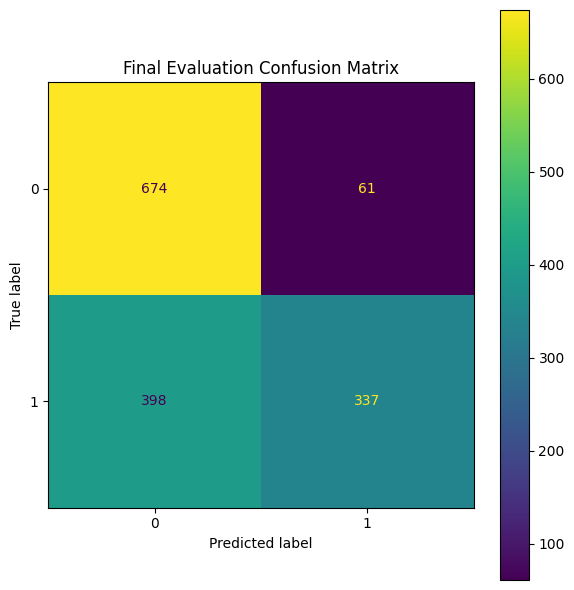

In [24]:
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test_final,
    final_predictions,
    ax=ax,
    values_format="d"
)

ax.set_title(
    "Final Evaluation Confusion Matrix"
)

plt.tight_layout()
plt.show()


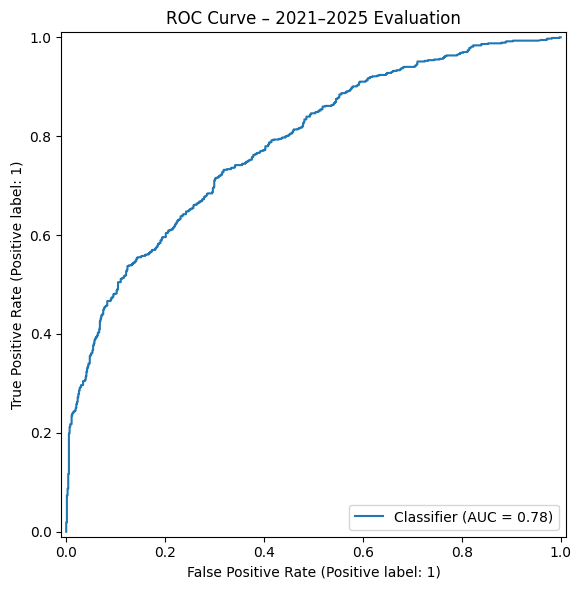

In [25]:
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test_final,
    final_probabilities,
    ax=ax
)

ax.set_title(
    "ROC Curve – 2021–2025 Evaluation"
)

plt.tight_layout()
plt.show()


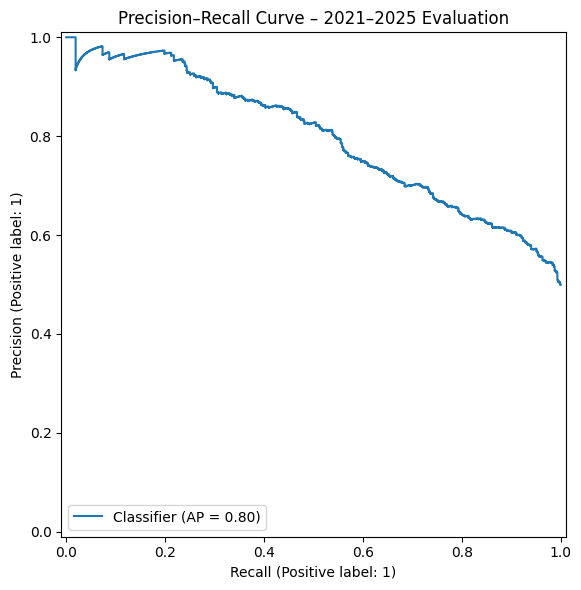

In [26]:
fig, ax = plt.subplots(figsize=(7, 6))

PrecisionRecallDisplay.from_predictions(
    y_test_final,
    final_probabilities,
    ax=ax
)

ax.set_title(
    "Precision–Recall Curve – 2021–2025 Evaluation"
)

plt.tight_layout()
plt.show()


### 16. Attach Prediction Scores


In [27]:
future_predictions_df = (
    final_features_df[
        [
            "actor_1",
            "actor_2",
            "label"
        ]
    ]
    .copy()
)

future_predictions_df[
    "prediction_score"
] = final_probabilities

future_predictions_df[
    "predicted_label"
] = final_predictions

future_predictions_df = (
    future_predictions_df
    .sort_values(
        "prediction_score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    future_predictions_df.head(20)
)


,actor_1,actor_2,label,prediction_score,predicted_label
0,אורלי זילברשץ,רן דנקר,1,0.999844,1
1,מאיר סוויסה,רן דנקר,1,0.999807,1
2,רועי אסף,שמעון מימרן,1,0.999802,1
3,חנן סביון,יוסי מרשק,1,0.999752,1
4,אוהד קנולר,רועי אסף,1,0.999517,1
5,אלברט אילוז,רועי אסף,1,0.999362,1
6,זאב רווח,ריימונד אמסלם,1,0.999344,1
7,יוסי מרשק,יעל אבקסיס,1,0.999344,1
8,אורי הוכמן,יוסי מרשק,1,0.999326,1
9,אורי פפר,יוסי מרשק,1,0.999281,1


### 17. Add Future Movie Evidence


In [30]:
future_period_df = edge_records_df[
    edge_records_df["year"].between(
        FINAL_FUTURE_START,
        FINAL_FUTURE_END
    )
].copy()

future_period_df["edge"] = future_period_df.apply(
    lambda row: canonical_edge(
        row["actor_1"],
        row["actor_2"]
    ),
    axis=1
)

# Keep the first observed future collaboration for each actor pair
future_period_df = (
    future_period_df
    .sort_values("year")
    .drop_duplicates(
        subset="edge",
        keep="first"
    )
)

future_movie_lookup = {
    row.edge: {
        "movie_title": row.movie_title,
        "year": int(row.year)
    }
    for row in future_period_df.itertuples(index=False)
}


def add_future_movie_details(dataframe):
    """Add the first observed future movie and year."""
    result = dataframe.copy()

    future_movies = []
    future_years = []

    for row in result.itertuples(index=False):
        edge = canonical_edge(
            row.actor_1,
            row.actor_2
        )

        details = future_movie_lookup.get(edge)

        if details is not None:
            future_movies.append(
                details["movie_title"]
            )
            future_years.append(
                details["year"]
            )
        else:
            future_movies.append("")
            future_years.append(np.nan)

    result["future_movie"] = future_movies
    result["future_year"] = future_years

    return result

### 18. High-Score Predictions That Were Realized


In [31]:
realized_high_score_df = (
    future_predictions_df[
        future_predictions_df["label"].eq(1)
    ]
    .sort_values(
        "prediction_score",
        ascending=False
    )
    .head(30)
)

realized_high_score_df = (
    add_future_movie_details(
        realized_high_score_df
    )
)

display(
    realized_high_score_df
)


,actor_1,actor_2,label,prediction_score,predicted_label,future_movie,future_year
0,אורלי זילברשץ,רן דנקר,1,0.999844,1,אחד בלב,2021
1,מאיר סוויסה,רן דנקר,1,0.999807,1,אחד בלב,2021
2,רועי אסף,שמעון מימרן,1,0.999802,1,מופע טוטאל,2025
3,חנן סביון,יוסי מרשק,1,0.999752,1,זרים מושלמים (סרט ישראלי),2021
4,אוהד קנולר,רועי אסף,1,0.999517,1,מופע טוטאל,2025
5,אלברט אילוז,רועי אסף,1,0.999362,1,מופע טוטאל,2025
6,זאב רווח,ריימונד אמסלם,1,0.999344,1,שער הפרחים (סרט),2022
7,יוסי מרשק,יעל אבקסיס,1,0.999344,1,כי את מכוערת,2025
8,אורי הוכמן,יוסי מרשק,1,0.999326,1,מזל חתולה,2024
9,אורי פפר,יוסי מרשק,1,0.999281,1,גרגירי חול,2023


### 19. High-Score Predictions That Were Not Realized


In [32]:
unrealized_high_score_df = (
    future_predictions_df[
        future_predictions_df["label"].eq(0)
    ]
    .sort_values(
        "prediction_score",
        ascending=False
    )
    .head(30)
)

display(
    unrealized_high_score_df
)


,actor_1,actor_2,label,prediction_score,predicted_label
14,ישי גולן,לירון בן-שלוש,0,0.999119,1
55,אריה מוסקונה,שלומי קוריאט,0,0.994938,1
66,איתמר רוטשילד,מנשה נוי,0,0.992908,1
89,יואב לוי,ירון מוטולה,0,0.988987,1
150,דויד וילחובסקי,נעמי פולני,0,0.966048,1
161,אביב אלוש,יורם יוספסברג,0,0.960967,1
166,חנה לסלאו,חני נחמיאס,0,0.958910,1
167,איריס בר,נועה וולמן,0,0.958178,1
181,אביגיל אריאלי,שאול מזרחי,0,0.946467,1
185,ג'נלין זוניו לוט,מאיר סויסה,0,0.942132,1


### 20. False-Negative Analysis


In [33]:
false_negative_df = (
    future_predictions_df[
        future_predictions_df["label"].eq(1)
        & future_predictions_df[
            "predicted_label"
        ].eq(0)
    ]
    .sort_values(
        "prediction_score",
        ascending=True
    )
)

false_negative_df = add_future_movie_details(
    false_negative_df
)

print(
    "False negatives:",
    len(false_negative_df)
)

display(
    false_negative_df.head(30)
)


False negatives: 398


,actor_1,actor_2,label,prediction_score,predicted_label,future_movie,future_year
1467,גבי דן,עודד מנסטר,1,0.000003,0,"תמונות יפואיות (סרט, 2024)",2025
1455,מוטי בן ישי,עודד מנסטר,1,0.000014,0,"תמונות יפואיות (סרט, 2024)",2025
1447,ג'וליה מסלאווי,עודד מנסטר,1,0.000017,0,"תמונות יפואיות (סרט, 2024)",2025
1445,אולג לוין,עודד מנסטר,1,0.000017,0,הארוחה,2023
1434,דודו באוכנר,עודד מנסטר,1,0.000020,0,הארוחה,2023
1393,אילנית בן יעקב,אילנית בן-יעקב,1,0.000048,0,עקרה (סרט),2022
1382,אילנית בן-יעקב,ג'יטה מונטה,1,0.000065,0,טור פרידה,2023
1380,אילנית בן-יעקב,תום חגי,1,0.000067,0,10 חודשים,2024
1373,אדם גבאי,אימרי ביטון,1,0.000075,0,"סבוי (סרט, 2022)",2022
1352,דור הררי,יותם קושניר,1,0.000109,0,המנצחים (סרט),2023


In [34]:
false_negative_analysis_df = (
    final_features_df[
        [
            "actor_1",
            "actor_2",
            "common_neighbors",
            "jaccard",
            "adamic_adar",
            "preferential_attachment",
            "shortest_path",
            "same_community",
            "degree_sum",
            "pagerank_sum",
            "label"
        ]
    ]
    .merge(
        false_negative_df[
            [
                "actor_1",
                "actor_2",
                "prediction_score",
                "future_movie",
                "future_year"
            ]
        ],
        on=[
            "actor_1",
            "actor_2"
        ],
        how="inner"
    )
    .sort_values(
        "prediction_score",
        ascending=True
    )
)

display(
    false_negative_analysis_df.head(30)
)


,actor_1,actor_2,common_neighbors,jaccard,adamic_adar,preferential_attachment,shortest_path,same_community,degree_sum,pagerank_sum,label,prediction_score,future_movie,future_year
40,גבי דן,עודד מנסטר,0,0.000000,0.000000,15,8,0,16,0.000901,1,0.000003,"תמונות יפואיות (סרט, 2024)",2025
35,מוטי בן ישי,עודד מנסטר,0,0.000000,0.000000,20,8,0,21,0.000988,1,0.000014,"תמונות יפואיות (סרט, 2024)",2025
62,ג'וליה מסלאווי,עודד מנסטר,0,0.000000,0.000000,18,8,0,19,0.000933,1,0.000017,"תמונות יפואיות (סרט, 2024)",2025
305,אולג לוין,עודד מנסטר,0,0.000000,0.000000,18,8,0,19,0.000921,1,0.000017,הארוחה,2023
13,דודו באוכנר,עודד מנסטר,0,0.000000,0.000000,9,8,0,10,0.000724,1,0.000020,הארוחה,2023
178,אילנית בן יעקב,אילנית בן-יעקב,0,0.000000,0.000000,63,3,0,16,0.000560,1,0.000048,עקרה (סרט),2022
188,אילנית בן-יעקב,ג'יטה מונטה,0,0.000000,0.000000,63,3,0,16,0.000558,1,0.000065,טור פרידה,2023
227,אילנית בן-יעקב,תום חגי,0,0.000000,0.000000,63,3,0,16,0.000563,1,0.000067,10 חודשים,2024
203,אדם גבאי,אימרי ביטון,0,0.000000,0.000000,72,3,0,17,0.000500,1,0.000075,"סבוי (סרט, 2022)",2022
1,דור הררי,יותם קושניר,0,0.000000,0.000000,54,3,0,15,0.000498,1,0.000109,המנצחים (סרט),2023


### 21. Cold-Start Analysis


In [35]:
cold_start_rows = []

for actor_1, actor_2 in sorted(
    final_cold_start_edges
):
    cold_start_rows.append({
        "actor_1": actor_1,
        "actor_2": actor_2,
        "actor_1_seen_before_2021":
            actor_1 in G_final,
        "actor_2_seen_before_2021":
            actor_2 in G_final
    })

cold_start_df = pd.DataFrame(
    cold_start_rows
)

print(
    "Cold-start future links:",
    len(cold_start_df)
)

display(
    cold_start_df.head(30)
)


Cold-start future links: 2001


,actor_1,actor_2,actor_1_seen_before_2021,actor_2_seen_before_2021
0,אבא קובנר,אוגוסט דיהל,False,False
1,אבא קובנר,אמיתי קדר,False,False
2,אבא קובנר,הבריגדה היהודית,False,False
3,אבא קובנר,יואל רוזנקיאר,False,True
4,אבא קובנר,ישי גולן,False,True
5,אבא קובנר,מיכאל אלוני,False,True
6,אבא קובנר,ניצול שואה,False,False
7,אבא קובנר,ניקולאי קינסקי,False,False
8,אבא קובנר,עוז זהבי,False,True
9,אבו עמר,אביתר אדרי,False,False


### 22. Feature Importance


In [38]:
print(type(best_model))
print(BEST_MODEL_NAME)

<class 'sklearn.ensemble._hist_gradient_boosting.gradient_boosting.HistGradientBoostingClassifier'>
HistGradientBoosting


In [39]:
from sklearn.inspection import permutation_importance

permutation_result = permutation_importance(
    best_model,
    X_test_final,
    y_test_final,
    scoring="roc_auc",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

feature_importance_df = (
    pd.DataFrame({
        "feature": BEST_FEATURE_COLUMNS,
        "importance": permutation_result.importances_mean,
        "std": permutation_result.importances_std
    })
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    feature_importance_df.head(20)
)

,feature,importance,std
0,clustering_mean,0.039649,0.003504
1,spectral_l1,0.030646,0.004225
2,pagerank_sum,0.021782,0.004057
3,preferential_attachment,0.018046,0.002884
4,degree_min,0.014431,0.004909
5,spectral_dot,0.004809,0.003108
6,adamic_adar,0.004276,0.002739
7,weighted_degree_sum,0.001849,0.001222
8,shortest_path,0.000577,0.000707
9,same_community,0.000449,0.000319


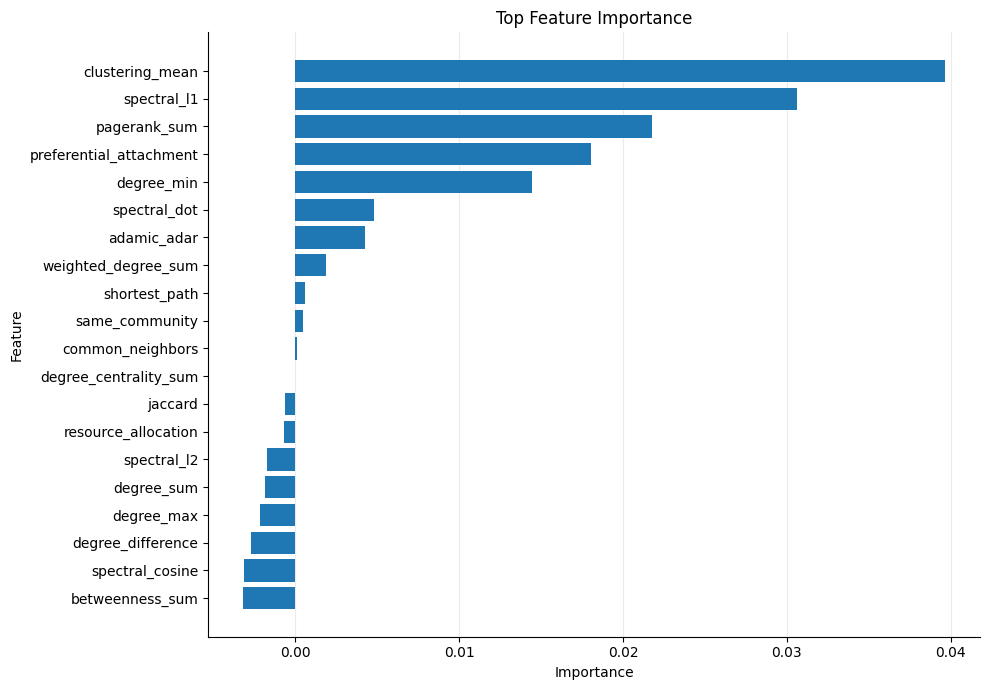

In [40]:
if not feature_importance_df.empty:
    plot_df = (
        feature_importance_df
        .head(20)
        .sort_values(
            "importance",
            ascending=True
        )
    )

    fig, ax = plt.subplots(
        figsize=(10, 7)
    )

    ax.barh(
        plot_df["feature"],
        plot_df["importance"]
    )

    ax.set_title(
        "Top Feature Importance"
    )
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(
        axis="x",
        alpha=0.25
    )
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()


### 23. Conclusions


In [41]:
print("Link Prediction Summary")
print("-" * 35)

print(
    "Selected feature set:",
    BEST_FEATURE_SET
)

print(
    "Selected model:",
    BEST_MODEL_NAME
)

print(
    "Final Precision:",
    f"{final_metrics['Precision']:.4f}"
)

print(
    "Final Recall:",
    f"{final_metrics['Recall']:.4f}"
)

print(
    "Final F1-score:",
    f"{final_metrics['F1']:.4f}"
)

print(
    "Final ROC-AUC:",
    f"{final_metrics['ROC-AUC']:.4f}"
)

print(
    "Final Average Precision:",
    f"{final_metrics['Average Precision']:.4f}"
)

print(
    "False negatives:",
    len(false_negative_df)
)

print(
    "Cold-start future links that could not be scored:",
    len(cold_start_df)
)


Link Prediction Summary
-----------------------------------
Selected feature set: Graph + Spectral
Selected model: HistGradientBoosting
Final Precision: 0.8467
Final Recall: 0.4585
Final F1-score: 0.5949
Final ROC-AUC: 0.7835
Final Average Precision: 0.7980
False negatives: 398
Cold-start future links that could not be scored: 2001


### 24. Limitations

- The model cannot score collaborations involving actors who were absent from the historical graph.
- Wikipedia data may be incomplete or inconsistent.
- A missing collaboration through 2025 does not prove that a high-score prediction is permanently incorrect.
- Negative examples are sampled because the complete non-edge set is extremely large.
- The balanced evaluation set does not represent the naturally severe imbalance of all possible actor pairs.
- Centrality and latent representations are recalculated using historical data only to prevent temporal leakage.


### 25. Export Results


In [42]:
model_comparison_df.to_csv(
    "link_prediction_model_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

final_metrics_df.to_csv(
    "future_evaluation_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

future_predictions_df.to_csv(
    "future_test_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

realized_high_score_df.to_csv(
    "realized_high_score_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

unrealized_high_score_df.to_csv(
    "unrealized_high_score_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

false_negative_analysis_df.to_csv(
    "false_negative_analysis.csv",
    index=False,
    encoding="utf-8-sig"
)

cold_start_df.to_csv(
    "cold_start_links.csv",
    index=False,
    encoding="utf-8-sig"
)

feature_importance_df.to_csv(
    "feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

with open(
    "best_link_prediction_model.pkl",
    "wb"
) as file:
    pickle.dump({
        "model": best_model,
        "feature_columns": BEST_FEATURE_COLUMNS,
        "feature_set": BEST_FEATURE_SET,
        "model_name": BEST_MODEL_NAME
    }, file)

print("Saved link-prediction analysis files.")


Saved link-prediction analysis files.
